# 01 — Verificación del modelo Saint-Venant 1D

Verifica que el solver en `src/model.py` produce resultados físicamente razonables antes de calibrar.
La única celda que el usuario debe modificar es la de **Configuración**.

## Modelo

$$\frac{\partial A}{\partial t} + \frac{\partial Q}{\partial x} = 0 \qquad\qquad \frac{\partial Q}{\partial t} + \!\frac{\partial}{\partial x}\frac{Q^2}{A} + \frac{\partial}{\partial x}\frac{hgA}{2}\ - gA(S_0 - S_f) = 0$$

Canal rectangular: $\;A = B_w h,\quad R = A\,/\,(B_w+2h),\quad S_f = n^2 Q|Q|\,/\,(A^2 R^{4/3})$

## Esquema numérico — MacCormack

**Predictor** : $\quad\hat{U}_i = U_i - \dfrac{\Delta t}{\Delta x}(F_{i+1}-F_i) + \Delta t\,S_i$

**Corrector** : $\quad U_i^{n+1} = \tfrac{1}{2}\!\left[U_i + \hat{U}_i - \dfrac{\Delta t}{\Delta x}(\hat{F}_i - \hat{F}_{i-1}) + \Delta t\,\hat{S}_i\right]$

**CFL**: $\;\Delta t \leq 0.9\,\Delta x\;/\max_i(|u_i|+\sqrt{gh_i})$

**CI**: $h(x,0)=h_n(Q_0),\;Q(x,0)=Q_0$ $\quad$ **CB**: $Q(0,t)=Q_\text{in}(t)$ aguas arriba; gradiente nulo en $x=L$

In [1]:
import sys
import importlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from joblib import Parallel, delayed

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import src.model as _model_module
importlib.reload(_model_module)
from src.model import saint_venant_1d, run_batch, normal_depth

FIGURES_DIR = ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

TRUE_PARAMS = [0.035, 0.001, 50.0]   # [n, S0, B_w], parametros definidos por parte del usuario o grupo de proyecto

df_params = pd.DataFrame({
    "Parámetro":        ["Manning (n)", "Pendiente de fondo (S₀)", "Ancho del canal (B_w)"],
    "Símbolo":          ["n",           "S₀",                      "B_w"],
    "Valor verdadero":  [0.035,         0.001,                     50.0],
    "Rango calibración":["0.010–0.060", "0.0001–0.005",            "20–80"],
    "Unidades":         ["—",           "—",                       "m"],
})
df_dominio = pd.DataFrame({
    "Variable": ["Longitud (L)", "Celdas (nx)", "Δx", "Estabilidad CFL"],
    "Valor":    ["5 000 m",      "100",          "50 m", "0.9 · Δx / (|u| + √(gh))"],
})
print("=== Parámetros calibrables ===")
display(df_params)
print("\n=== Dominio numérico ===")
display(df_dominio)

=== Parámetros calibrables ===


,Parámetro,Símbolo,Valor verdadero,Rango calibración,Unidades
0,Manning (n),n,0.035,0.010–0.060,—
1,Pendiente de fondo (S₀),S₀,0.001,0.0001–0.005,—
2,Ancho del canal (B_w),B_w,50.000,20–80,m



=== Dominio numérico ===


,Variable,Valor
0,Longitud (L),5 000 m
1,Celdas (nx),100
2,Δx,50 m
3,Estabilidad CFL,0.9 · Δx / (|u| + √(gh))


## Configuración
Única celda que se modifica para cambiar el dataset.

In [2]:
CSV_PATH = ROOT / "data" / "synthetic" / "series_corta_balance.csv"

resultado = run_batch(str(CSV_PATH), TRUE_PARAMS)
print(f"Filas totales : {len(resultado):,}")
print(f"Filas warmup  : {resultado['is_warmup'].sum()}")
print((resultado.keys()))
display(resultado.head())

Filas totales : 500
Filas warmup  : 4
Index(['datetime', 'Q_upstream_m3s', 'Q_downstream_m3s', 'h_outlet_m',
       'Q_sim_m3s', 't_seconds', 'is_warmup', 'residual_m3s'],
      dtype='object')


,datetime,Q_upstream_m3s,Q_downstream_m3s,h_outlet_m,Q_sim_m3s,t_seconds,is_warmup,residual_m3s
0,2022-01-01 00:00:00,38.711,38.711,0.9115,38.711,0.0,True,0.000
1,2022-01-01 00:15:00,38.709,38.709,0.9115,38.711,900.0,True,-0.002
2,2022-01-01 00:30:00,38.706,38.706,0.9114,38.711,1800.0,True,-0.005
3,2022-01-01 00:45:00,38.704,38.704,0.9114,38.711,2700.0,True,-0.007
4,2022-01-01 01:00:00,38.701,38.701,0.9114,38.711,3600.0,False,-0.010


## Verificación — Propagación del hidrograma

El modelo recibe Q(t) en x=0 (aguas arriba) y propaga la onda hasta x=L mediante el esquema MacCormack. Las tres curvas muestran la entrada al canal, la salida simulada en x=L y la referencia sintética generada con los parámetros verdaderos. Se espera que la onda llegue atenuada y desfasada.

In [ ]:
# Usar resultados ya calculados por run_batch
t_min      = resultado['t_seconds'].to_numpy() / 60
q_upstream = resultado['Q_upstream_m3s'].to_numpy()
q_sim_dn   = resultado['Q_sim_m3s'].to_numpy()
q_dn_obs   = resultado['Q_downstream_m3s'].to_numpy()
is_warmup  = resultado['is_warmup'].to_numpy()

t_wu_end = t_min[(~is_warmup).argmax()] if (~is_warmup).any() else t_min[-1]

fig, ax = plt.subplots(figsize=(11, 4))
ax.axvspan(t_min[0], t_wu_end, color='gray', alpha=0.12, label='Warm-up')
ax.plot(t_min, q_upstream, color='0.55', lw=1.0, ls='--', label='Q entrada (x=0)')
ax.plot(t_min, q_sim_dn,   color='steelblue', lw=1.6, label='Q simulado (x=L)')
ax.plot(t_min, q_dn_obs,   color='crimson',   lw=1.0, ls=':',  label='Q referencia sintetica (x=L)')
ax.set_xlabel('Tiempo [min]')
ax.set_ylabel('Q [m3/s]')
ax.set_title('Propagacion del hidrograma — entrada, salida simulada y referencia sintetica')
ax.legend(fontsize=9)
plt.tight_layout()
fig.savefig(FIGURES_DIR / '01a_variable_upstream.png', dpi=200)
plt.show()

print(f'Max desviacion |Q_sim - Q_ref|: {np.max(np.abs(q_sim_dn - q_dn_obs)):.4f} m3/s')


## Métricas cuantitativas de ajuste

NSE, RMSE, sesgo y correlación calculados sobre el período post-calentamiento (columna `is_warmup == False`). Para datos sintéticos sin ruido se espera NSE ≈ 1 y RMSE ≈ 0.

In [ ]:
eval_df = resultado[~resultado['is_warmup']]
obs = eval_df['Q_downstream_m3s'].to_numpy()
sim = eval_df['Q_sim_m3s'].to_numpy()

mae   = np.mean(np.abs(obs - sim))
rmse  = np.sqrt(np.mean((obs - sim) ** 2))
bias  = np.mean(sim - obs)
r     = np.corrcoef(obs, sim)[0, 1]
denom = np.sum((obs - np.mean(obs)) ** 2)
nse   = float(1.0 - np.sum((obs - sim) ** 2) / denom) if denom > 0 else float('nan')

metricas = pd.Series({
    'NSE':          nse,
    'MAE [m³/s]':   mae,
    'RMSE [m³/s]':  rmse,
    'Bias [m³/s]':  bias,
    'r':            r,
}).to_frame('valor').round(4)
display(metricas)

# Scatter obs vs sim (figura de verificacion estandar)
lim = [min(obs.min(), sim.min()) * 0.97, max(obs.max(), sim.max()) * 1.03]
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(obs, sim, s=10, alpha=0.4, color='steelblue', edgecolors='none')
ax.plot(lim, lim, 'k--', lw=1.2, label='1:1')
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel('Q observado [m³/s]')
ax.set_ylabel('Q simulado [m³/s]')
ax.set_title(f'Dispersión obs vs sim — NSE={nse:.4f}  r={r:.4f}')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


## Test B — Conservación de masa
Volumen acumulado de entrada vs. salida a lo largo de toda la serie.

In [ ]:
t_arr  = resultado['t_seconds'].to_numpy()
dt_arr = np.diff(t_arr, prepend=t_arr[0])
dt_arr[0] = dt_arr[1]

V_in  = np.cumsum(resultado['Q_upstream_m3s'].to_numpy() * dt_arr)
V_out = np.cumsum(resultado['Q_sim_m3s'].to_numpy()       * dt_arr)
err_rel = (V_in[-1] - V_out[-1]) / V_in[-1] * 100
print(f'Error de masa relativo (total): {err_rel:.4f} %')

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(resultado['datetime'], resultado['Q_upstream_m3s'],
             label='Q upstream', alpha=0.8)
axes[0].plot(resultado['datetime'], resultado['Q_sim_m3s'],
             label='Q sim salida', alpha=0.8, ls='--')
axes[0].set_ylabel('Q [m³/s]')
axes[0].legend()
axes[0].set_title('Test B — Conservación de masa (hidrograma)')

axes[1].plot(resultado['datetime'], V_in  / 1e6, label='Vol. acumulado entrada [Mm³]')
axes[1].plot(resultado['datetime'], V_out / 1e6, label='Vol. acumulado salida [Mm³]', ls='--')
axes[1].set_ylabel('Volumen acumulado [Mm³]')
axes[1].set_xlabel('Fecha')
axes[1].legend()
axes[1].set_title(f'Volumen acumulado — Error relativo: {err_rel:.4f} %')

plt.tight_layout()
fig.savefig(FIGURES_DIR / '01b_mass_conservation.png', dpi=200)
plt.show()


## Demo — Paralelización con joblib
Muestra cómo lanzar múltiples simulaciones en paralelo; patrón que usarán Sobol y GLUE.

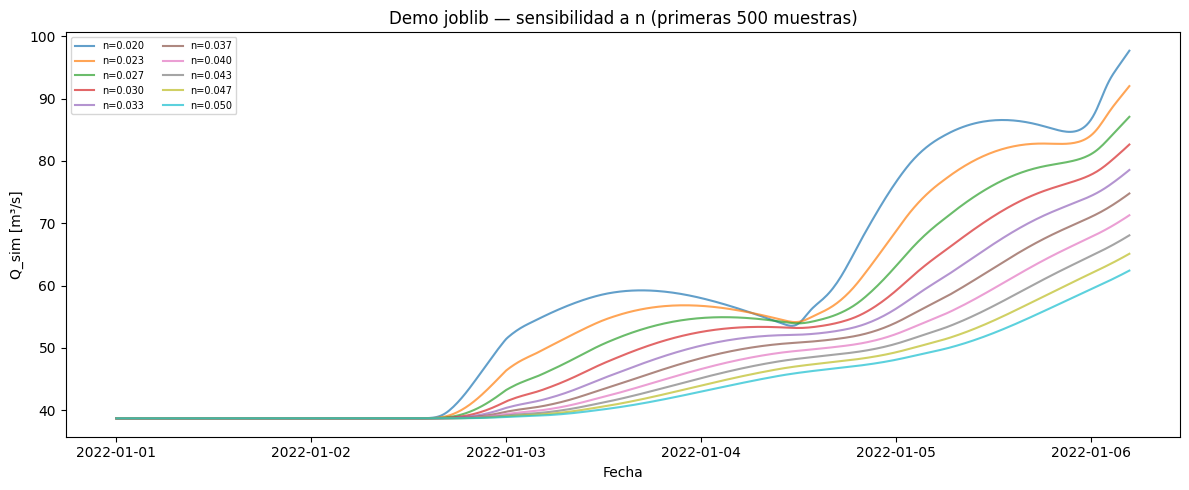

10 simulaciones en paralelo completadas.


In [6]:
n, S0, B_w = TRUE_PARAMS
q_up  = resultado["Q_upstream_m3s"].to_numpy()
t_sec = resultado["t_seconds"].to_numpy()
n_vals = np.linspace(0.020, 0.050, 10)

def _run_one(n_val):
    return saint_venant_1d([n_val, S0, B_w], q_up, t_sec)

Q_parallel = Parallel(n_jobs=-1)(delayed(_run_one)(nv) for nv in n_vals)

WIN = 500
fig, ax = plt.subplots(figsize=(12, 5))
for nv, Q_s in zip(n_vals, Q_parallel):
    ax.plot(resultado["datetime"].iloc[:WIN], Q_s[:WIN], alpha=0.7, label=f"n={nv:.3f}")
ax.set_xlabel("Fecha")
ax.set_ylabel("Q_sim [m³/s]")
ax.set_title("Demo joblib — sensibilidad a n (primeras 500 muestras)")
ax.legend(fontsize=7, ncol=2)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "01c_joblib_demo.png", dpi=200)
plt.show()

print(f"{len(n_vals)} simulaciones en paralelo completadas.")